# Siemens- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from suport import *
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 

## 2. Data importation

In [ ]:
file_path_CRC = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\crc.parquet"
file_path_CREDSCORE = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\credscore.parquet"
file_path_BDOSS = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\bdoss.parquet"
file_path_FAMA = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\fama.parquet"

CRC = pd.read_parquet(file_path_CRC, engine="fastparquet")
CREDSCORE = pd.read_parquet(file_path_CREDSCORE, engine="fastparquet")
FAMA = pd.read_parquet(file_path_FAMA, engine="fastparquet")
BDOSS = pd.read_parquet(file_path_BDOSS, engine="fastparquet")

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# CRC Dataset
       
</div>


## 3. Data exploration and understanding

**METADATA:**


### 3.1. Data Overview

In [3]:
#overview the dataset
CRC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3034921 entries, 0 to 3034920
Data columns (total 22 columns):
 #   Column          Dtype         
---  ------          -----         
 0   CONTRIB         object        
 1   OBS_DATE        datetime64[ns]
 2   MT_MENSAL       float64       
 3   COUNT_CL        float64       
 4   COUNT_CP        float64       
 5   COUNT_AUTO      float64       
 6   COUNT_HT        float64       
 7   COUNT_CONEXO    float64       
 8   COUNT_OTHER     float64       
 9   COUNT_TOTAL     float64       
 10  MONTVENC_CL     float64       
 11  MONTVENC_CP     float64       
 12  MONTVENC_AUTO   float64       
 13  MONTVENC_HT     float64       
 14  MONTABATV_CL    float64       
 15  MONTABATV_CP    float64       
 16  MONTABATV_AUTO  float64       
 17  MONTABATV_HT    float64       
 18  DIVIDAS_CL      float64       
 19  DIVIDAS_CP      float64       
 20  DIVIDAS_AUTO    float64       
 21  DIVIDAS_HT      float64       
dtypes: datetime64[ns](

At first sight we can understand that: 
- The most important (serious ones) are the MONTABATV. If those variables are too high, the client is not trustworthy.
- It is normal for a client to have "DIVIDAS", but is preferable if they reduce month to month.

In [4]:
#first 20 rows
CRC.head(20)

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6842.10,963.55,0.00,0.00
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,2023-12-31,547.18,4.0,5.0,0.0,0.0,0.0,1.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,28532.06,7115.46,0.00,0.00
2,0000f858346061c53064586a3347b34659565a6712d004...,2023-12-31,NaN,1.0,5.0,1.0,1.0,0.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2957.28,2150.90,2408.56,85549.49
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,2023-12-31,515.57,3.0,1.0,0.0,0.0,0.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,27120.42,152.95,0.00,0.00
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,2023-12-31,NaN,8.0,3.0,0.0,0.0,0.0,1.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,46104.39,4128.54,0.00,0.00
5,000508d6436a34b780df1aa8068568f1b118f5d589ddc7...,2023-12-31,NaN,0.0,5.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1219.82,0.00,0.00
6,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,2023-12-31,113.79,1.0,2.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3876.44,273.70,0.00,0.00
7,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a9...,2023-12-31,1802.33,4.0,3.0,0.0,1.0,0.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,33512.86,12494.52,0.00,169533.98
8,000607d1adce7aa9ac87274d1a2ffa84e240188de0872f...,2023-12-31,NaN,0.0,4.0,0.0,1.0,1.0,1.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,4803.57,0.00,50195.43
9,00063f4ff357806252119717d819d2f5acb3bc68cf56a7...,2023-12-31,93.64,1.0,1.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3233.72,3570.00,0.00,0.00


In [6]:
#descriptive statistics for numerical data
CRC.describe().round(2)

,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
count,3034921,1029718.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,...,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00
mean,2025-01-01 06:09:42.119141376,552.09,1.65,3.09,0.55,0.46,0.07,0.67,6.49,103.33,...,19.69,37.85,4.34,4.27,0.30,0.47,11438.98,2624.60,5403.67,30449.71
min,2023-12-31 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2024-06-30 00:00:00,236.67,1.00,2.00,0.00,0.00,0.00,0.00,4.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1128.30,132.84,0.00,0.00
50%,2024-12-31 00:00:00,446.60,1.00,3.00,0.00,0.00,0.00,0.00,6.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,6160.02,1133.66,0.00,0.00
75%,2025-06-30 00:00:00,724.99,2.00,4.00,1.00,1.00,0.00,1.00,8.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,15248.11,3219.76,8243.23,46515.51
max,2025-12-31 00:00:00,1224049.39,90.00,183.00,26.00,36.00,15.00,72.00,330.00,2923893.44,...,130756.11,807322.92,171424.67,62861.30,33127.84,288803.22,3194523.32,480181.93,514850.48,4582324.44
std,NaN,1736.58,1.65,2.41,0.76,0.73,0.30,0.88,4.07,2818.38,...,591.92,2541.25,285.17,209.89,59.54,211.27,17905.50,4414.23,9711.06,59607.22


### 3.2. Checking Duplicates

In [11]:
#checking number of duplicates
CRC.duplicated().sum()

np.int64(0)

### 3.3. Checking Missing Values

In [12]:
#checking number of missing values
CRC.isna().sum()

CONTRIB                 0
OBS_DATE                0
MT_MENSAL         2005203
COUNT_CL              172
COUNT_CP              172
COUNT_AUTO            172
COUNT_HT              172
COUNT_CONEXO          172
COUNT_OTHER           172
COUNT_TOTAL           172
MONTVENC_CL           172
MONTVENC_CP           172
MONTVENC_AUTO         172
MONTVENC_HT           172
MONTABATV_CL          172
MONTABATV_CP          172
MONTABATV_AUTO        172
MONTABATV_HT          172
DIVIDAS_CL            172
DIVIDAS_CP            172
DIVIDAS_AUTO          172
DIVIDAS_HT            172
dtype: int64

In [13]:
#checking umber of missing values in each column as a percentage
CRC.isna().sum()/len(CRC) * 100

CONTRIB            0.000000
OBS_DATE           0.000000
MT_MENSAL         66.071011
COUNT_CL           0.005667
COUNT_CP           0.005667
COUNT_AUTO         0.005667
COUNT_HT           0.005667
COUNT_CONEXO       0.005667
COUNT_OTHER        0.005667
COUNT_TOTAL        0.005667
MONTVENC_CL        0.005667
MONTVENC_CP        0.005667
MONTVENC_AUTO      0.005667
MONTVENC_HT        0.005667
MONTABATV_CL       0.005667
MONTABATV_CP       0.005667
MONTABATV_AUTO     0.005667
MONTABATV_HT       0.005667
DIVIDAS_CL         0.005667
DIVIDAS_CP         0.005667
DIVIDAS_AUTO       0.005667
DIVIDAS_HT         0.005667
dtype: float64

### 3.4. Checking Outliers

### 3.5. Checking Distribution

### 3.6. Checking Correlation between variables

In [40]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = CRC[metric_features].corr(method ='spearman')
cor_spearman

,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
MT_MENSAL,1.000000,0.395456,0.236308,0.231944,0.528161,0.272057,0.236045,0.558835,0.003648,-0.000568,0.016154,0.055819,-0.015057,-0.012127,-0.006622,-0.001455,0.533841,0.253331,0.266549,0.549654
COUNT_CL,0.395456,1.000000,0.204948,-0.183313,-0.006950,0.007571,0.086483,0.508537,0.166407,0.095022,0.025574,0.024357,0.022919,0.009356,-0.000684,0.000307,0.754133,0.321823,-0.153515,-0.014785
COUNT_CP,0.236308,0.204948,1.000000,-0.018989,0.130792,0.048963,0.223728,0.792283,-0.009487,0.065507,-0.021295,-0.004927,-0.006277,0.006749,-0.004314,-0.000484,0.197549,0.578446,-0.012727,0.122814
COUNT_AUTO,0.231944,-0.183313,-0.018989,1.000000,0.013875,0.015116,-0.035781,0.133008,-0.019078,-0.003135,0.136465,-0.001945,-0.001732,0.001956,0.011013,-0.003241,-0.231844,-0.033016,0.949972,0.016585
COUNT_HT,0.528161,-0.006950,0.130792,0.013875,1.000000,0.320383,0.221910,0.369609,-0.055014,-0.045006,-0.036792,0.113256,-0.009013,-0.011366,-0.005470,0.006431,0.014450,0.026859,0.011636,0.960529
COUNT_CONEXO,0.272057,0.007571,0.048963,0.015116,0.320383,1.000000,0.091806,0.195976,-0.018923,-0.018080,-0.010738,0.040709,-0.000477,-0.002240,-0.001672,-0.001178,0.017701,0.034912,0.012127,0.281941
COUNT_OTHER,0.236045,0.086483,0.223728,-0.035781,0.221910,0.091806,1.000000,0.464314,-0.006671,-0.008518,-0.019657,0.027521,-0.001341,0.000122,-0.001632,-0.001998,0.098743,0.129794,-0.035553,0.190432
COUNT_TOTAL,0.558835,0.508537,0.792283,0.133008,0.369609,0.195976,0.464314,1.000000,0.052153,0.069136,0.016794,0.041150,0.003689,0.006556,-0.001466,0.000327,0.398894,0.532123,0.133098,0.338988
MONTVENC_CL,0.003648,0.166407,-0.009487,-0.019078,-0.055014,-0.018923,-0.006671,0.052153,1.000000,0.464612,0.237175,0.113478,0.065208,0.077152,0.017712,0.007293,0.123688,0.078203,-0.017696,-0.055038
MONTVENC_CP,-0.000568,0.095022,0.065507,-0.003135,-0.045006,-0.018080,-0.008518,0.069136,0.464612,1.000000,0.230611,0.095578,0.050279,0.075669,0.011731,0.000846,0.074388,0.167852,-0.002428,-0.044053


In [41]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap=sns.light_palette("#798a40", as_cmap=True), #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

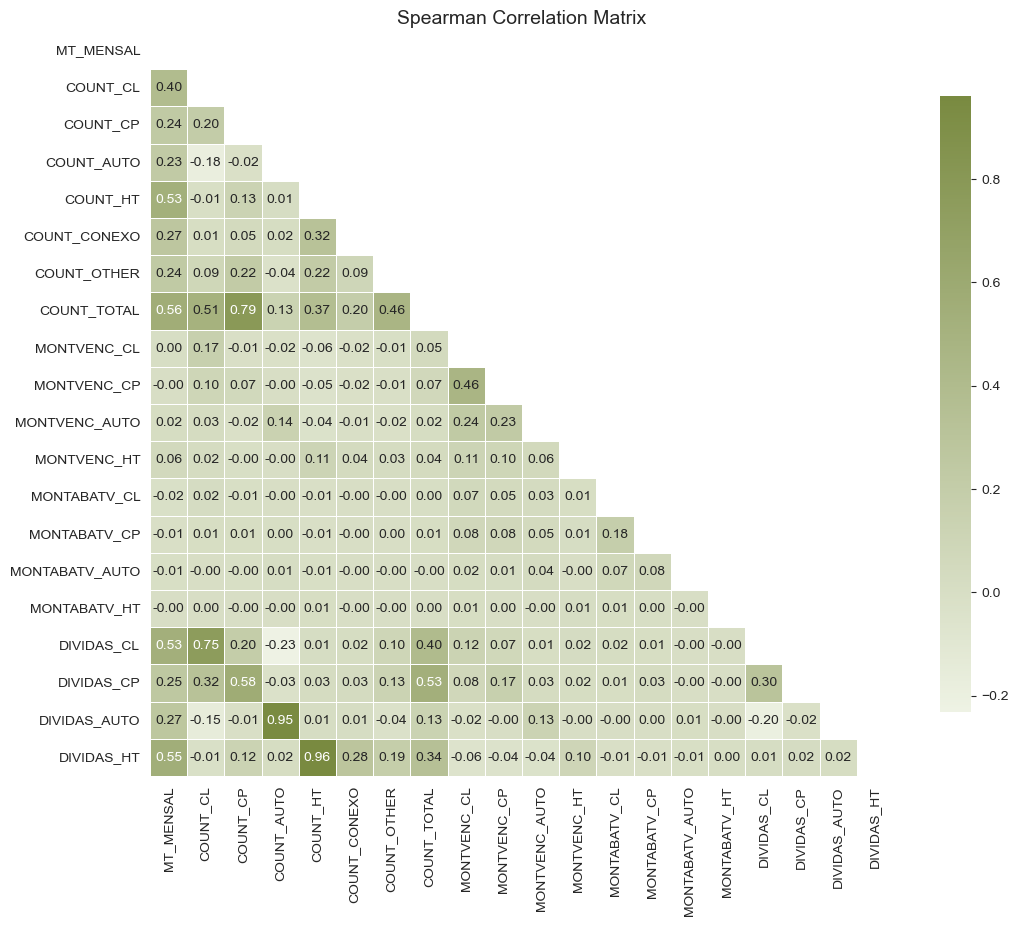

In [42]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

### 3.7. Checking Incoherencies

## 4. Data Preparation

### 4.1. Changing Datatypes

In [46]:
#Changing Datatypes
CRC['COUNT_CL'] = CRC['COUNT_CL'].round().astype('Int32')
CRC['COUNT_CP'] = CRC['COUNT_CP'].round().astype('Int32')
CRC['COUNT_AUTO'] = CRC['COUNT_AUTO'].round().astype('Int32')
CRC['COUNT_HT'] = CRC['COUNT_HT'].round().astype('Int32')
CRC['COUNT_CONEXO'] = CRC['COUNT_CONEXO'].round().astype('Int32')
CRC['COUNT_OTHER'] = CRC['COUNT_OTHER'].round().astype('Int32')
CRC['COUNT_TOTAL'] = CRC['COUNT_TOTAL'].round().astype('Int32')

### 4.2. Handling Missing Values

### 4.3. Handling Outliers

### 4.4. Feature Engineering

### 4.5. Data Aggregation